# Generación de mercados
En este notebook nos proponemos simular diferentes mercados paramétricamente y posteriormente analizar esas simulaciones tomando como criterio el realismo de estos. Usaremos como generadores, en este primer análisis, un movimiento browniano geométrico y un Merton jump diffusion, teniendo en cuenta que hemos desarrollado código para ajustar estos dos modelos a los datos. Con cada uno de estos generadores, crearemos en primer lugar un mercado que denominaremos normal, como puede ser el de un índice bursátil, y por otro lado un mercado de alta volatilidad, como lo puede ser el precio de una criptomoneda.

Antes de entrar en la simulación concreta de cada tipo de modelo, enumeraremos algunas de las ventajas generales que proporciona tener un modelo realista de los datos.

1. Permite estimar el retorno medio y la volatilidad de los datos.
2. Estimar distribuciones de P&G de una estrategia antes de ejecutarla. Por lo tanto, permite calcular probabilidad de alcanzar un target o tocar un stop-loss.
3. Permite contextualizar métricas como el VaR o el Expected Shortfall, para la distribución de precios simulada.

Para cada modelo, además de las posibles particularidades de cada modelo, analizaremos estos tres puntos contextualizados a cada modelo. Para 

## Movimiento browniano geométrico
En el notebook ```simulaciones.ipynb``` está la especificación del modelo y el la concreción del método de máxima verosimilitud para su ajuste a una serie de datos. Aquí, además de generar una simulación de mercado usando un generador ajustado a un mercado, como decimos, normal; subrallaremos propiedades de este tipo de modelo a tener en cuenta.

La primera observación que realizamos sobre este tipo de modelo es que la ecuación que define el modelo puede ser resuelta analíticamente, esto es, hay una formula para $S_t$:
$$S_t = S_0\exp\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma B_t\right).$$

De esta forma, la distribución de $S_t$ es conocida: se trata de una variable log-normal de media $\mathbb{E}[S_t] = S_0e^{\mu t}$, por lo que, en este modelo, estamos asumiendo que los precios de media siguen una curva exponencial. La expresión para la varianza es conocida, pero algo complicada. En todo caso, subrallamos que esta crece de forma exponencial con el paso del tiempo, lo cual supone un problema a la hora de realizar predicciones a largo plazo.

Hay otra forma de plantear lo anterior: en lugar de precios podemos analizar las propiedades de los retornos: $r_{t} = \log(S_{t+\Delta t}/S_t)$. En este caso sabemos que la ecuación que define $r_t$ es
$$ d\log(S_t) = \mu dt + \sigma dB_t. $$
En este caso $r_{t}$ sigue una distribución normal de media $\mu\Delta t$ y varianza $\sigma^2 \Delta t$. Es decir la distribución de los retornos es constante en el tiempo, a diferencia de la de los precios.

### Estimación de media y varianza

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datos
import SimulacionMonteCarlo

In [3]:
dd = datos.StockDataDownloader(source='fmp')
sp500 = dd.download("^GSPC")['close']

gbm = SimulacionMonteCarlo.GBM()
gbm.ajustar_parametros(sp500.values, M=100)
gbm.mostrar_parametros()

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:130: RuntimeWarning: invalid value encountered in log
  nlL = -np.sum([np.log(1/(np.sqrt(2*np.pi*new_params['Deltat'])*var_sigma))


Ajuste de parámetros realizado correctamente.
===== Parámetros del modelo =====
T:		1255
N:		1255
Deltat:		1.0
S0:		4180.17
M:		100
mu:		0.0004807788664615186
sigma:		0.010662258594470486


Obtenemos un retorno medio de 0,0004, y una desviación estándar de los retornos de 0,0106. Esto nos indica que el precio del activo tiene tendencia a crecer, aunque no mucho.

### Simulación de P&G
En primer lugar simulamos los precios con los parámetros mostrados anteriormente.

/tmp/ipykernel_4548/3230461547.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


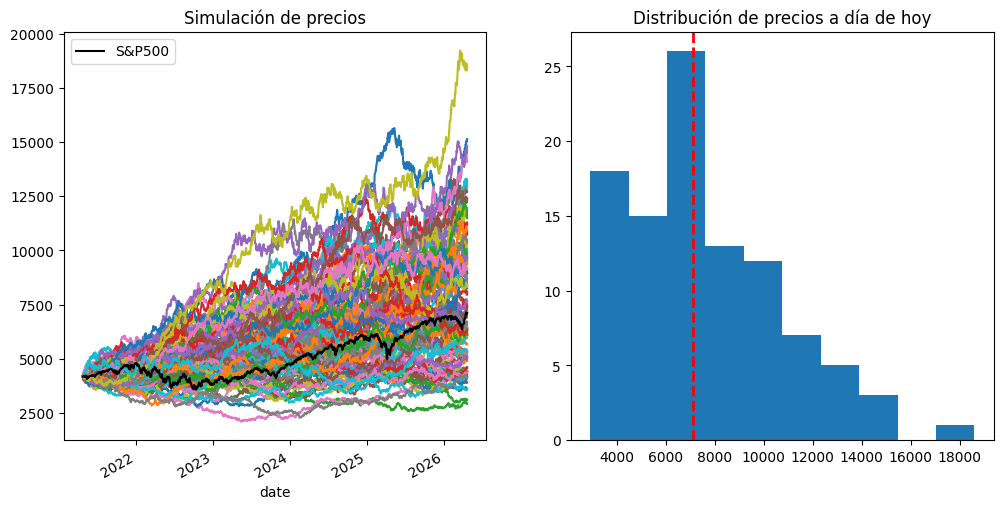

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

simulation = gbm.simular()[:-1, :]
simulation_df = pd.DataFrame(simulation, index=sp500.index)
simulation_df.plot(legend=False, ax=axes[0])

sp500.name = 'S&P500'
sp500.plot(legend=True,ax=axes[0], color='black')
axes[0].set_title('Simulación de precios')

axes[1].hist(x=simulation[-1, :])
axes[1].axvline(x=sp500.values[-1], color='red', linestyle='--', linewidth=2, label='Último precio real')
axes[1].set_title('Distribución de precios a día de hoy')

fig.show()

En el primer gráfico se muestra el resultado de ejecutar 100 simulaciones con los parámetros ajustados a los datos del sp500 desde el 23 de abril de 2021 hasta hoy, 22 de abril de 2026. Junto con la distribución del precio a día de hoy (según el modelo), nos permite tener una idea intuitiva del significado del parámetro $\sigma$. 

Seguidamente calculamos el vector de P&G a partir de esta simulación. Consideraremos una inversión de \$1 000 000 en el S&P500. Podríamos generar la variable retorno directamente, pero lo haremos a partir de la simulación para luego replicar el método con otros modelos.

                   0
count  125400.000000
mean      468.465395
std     10634.246399
min    -49502.640481
25%     -6661.107365
50%       482.854407
75%      7619.708450
max     48845.584285


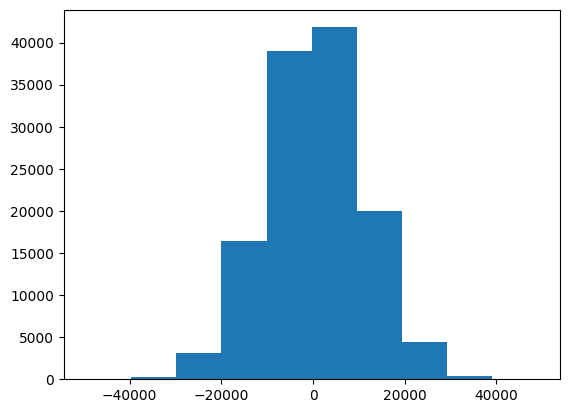

In [22]:
returns = np.diff(np.log(simulation), axis=0).flatten()
PandG = 1_000_000 * (np.exp(returns) - 1)
print(pd.DataFrame(PandG).describe())
plt.hist(PandG)
plt.show()


Como hemos dichos, los retornos siguen una distribución normal, con la media y varianza que hemos considerado anteriormente. El retorno de una inversión de \$1000000 para un día de horizonte temporal puede oscilar en una pérdida o ganancia de casi \$50 000. La ganancia que esperamos tener es de \$468 en un día.


## VaR y Expected Shortfall
Calculamos el VaR al 5\% para horizonte temporal de 1 día y el Expected Shortfall para esta simulación de P&G. Recordamos que estas son métricas para el control del riesgo que nos indican respectívamente que solo en un 5% de los casos vamos a tener caídas superiores al VaR (definición de VaR), y la media de las caídas superiores al VaR (definición de Expected Shortfall).

In [25]:
VaR_gbm = np.percentile(PandG, 0.05)
ES_gbm = np.mean(PandG[PandG < VaR_gbm])
print("VaR: {}".format(VaR_gbm))
print("Expected Shortfall: {}".format(ES_gbm))

VaR: -35075.49054116549
Expected Shortfall: -37975.35404437641


Observamos que el Expected Shortfall y el VaR no difieren en exceso, esto nos indica que la cola de pérdidas de la distribución no es excesivamente pronunciada (esto es conocido para la distribución normal).